In [ ]:
!apt-get install verilator
# prompt: download from https://github.com/WuShengHan/plot_ldpc/tree/main/open_WSH

!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/libwsh.so
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/main_wsh.cpp
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/ldpc_wsh.v


!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report1664_1024_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report1792_1024_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report1920_1024_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report2048_1024_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report2688_2048_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report2816_2048_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report2944_2048_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report3072_2048_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report4736_4096_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report4864_4096_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report4992_4096_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report5120_4096_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report8832_8192_QC64_DEG4.txt
!wget https://github.com/WuShengHan/plot_ldpc/raw/main/open_WSH/report/report8960_8192_QC64_DEG4.txt

!ls -ltra

In [ ]:
import os

avx_only = 1 #or 0; 0 will take 5~7 minuates to compile. Be patient.
run_mode = [7,8,9,10,11,12,13,14,15,0,1,4,5,6,]  #,16,17]
tlimit = "13m"  #30s, 2m, 5h

print("---------------------")
print(" Release ldpc_wsh.v, production-ready 2b LDPC-WSH ECC RTL-IP")
print("Commercial License (Action Required)")
print("Any use of this IP by a company, corporation, or for-profit entity requires a formal Commercial License Agreement. This includes, but is not limited to:")
print("- Integrating this IP into a commercial SoC, ASIC, or FPGA product.")
print("- Using this IP for internal corporate R&D, prototyping, or testing.")
print("- Inclusion in any paid service or consultancy project.")
print("Using this IP in a commercial environment without a valid license constitutes a breach of copyright law and will be subject to legal action.")
print(" *** Licensing Inquiry")
print("To obtain the Full RTL Source Code, Technical Support, or a Commercial License, please contact the author: ")
print("ShengHan Wu, from TW, by email: WuShengHan@outlook.com")
print("---------------------")

!perl -pi.bak -e "s|^float\s*sn_start\s*=.*$|float sn_start = 3.60;|"         main_wsh.cpp
!perl -pi.bak -e "s|^float\s*sn_step\s*=.*$|float sn_step = 0.20;|"           main_wsh.cpp
!perl -pi.bak -e "s|^long\s*snr_runs\s*=.*$|long  snr_runs     = 7000000;|"   main_wsh.cpp
### change random seed
!perl -pi.bak -e "s|^\s*\*idum\s*=.*\d\d\d.*$|    *idum = -12345; |"          main_wsh.cpp

### use hard-input to verify its error floor
#!perl -pi.bak -e "s|.*define\s*HARD_INPUT.*$|#define  HARD_INPUT|"           main_wsh.cpp

### dump vcd waveform to check verilog ip behavior, ex by gtkwave vcd viewer
!perl -pi.bak -e "s|.*define\s*DUMP_VCD.*$|//#define  DUMP_VCD|"              main_wsh.cpp

if avx_only:
    # -----------------------------------------
    #  Run AVX only to explore correction quality <<<--- super fast if more cpu cores
    # -----------------------------------------
    !g++ -DNO_VERILATOR main_wsh.cpp -L. -lwsh -Wl,-rpath=. -o Vldpc_wsh -lpthread
else:
    # -----------------------------------------
    # AVX-C function bit-turely cosim with synthesizable RTL ip.
    # ldpc_wsh.v matches AVX-C by timing cycles
    # -----------------------------------------
    #  warning: verilator compiling time would take 6~7 minutes
    !verilator --cc --trace --exe --Wno-lint --Wno-UNOPTFLAT --Wno-MODDUP --autoflush --top-module ldpc_wsh ldpc_wsh.v main_wsh.cpp   --Mdir cobj_dir -CFLAGS "-std=gnu++11 -L. -lwsh -Wl,-rpath=. -lpthread " -LDFLAGS "-L. -lwsh -Wl,-rpath=. -lpthread" -Wno-BLKANDNBLK
    !cp libwsh.so ./cobj_dir ; make -C cobj_dir -f Vldpc_wsh.mk ;  cp ./cobj_dir/Vldpc_wsh .

def to_sec(t):
    val, unit = int(t[:-1]), t[-1]
    return val * {'s': 1, 'm': 60, 'h': 3600}[unit]


for ii in run_mode:
    !timeout {tlimit} ./Vldpc_wsh {ii}
    if avx_only and to_sec(tlimit) > to_sec('10m'):
        !cat hstg.txt >> "$(ls -t report*.txt | head -n 1)"

print("---------------------")
print(" Release ldpc_wsh.v, production-ready 2b LDPC-WSH ECC RTL-IP")
print("Commercial License (Action Required)")
print("Any use of this IP by a company, corporation, or for-profit entity requires a formal Commercial License Agreement. This includes, but is not limited to:")
print("- Integrating this IP into a commercial SoC, ASIC, or FPGA product.")
print("- Using this IP for internal corporate R&D, prototyping, or testing.")
print("- Inclusion in any paid service or consultancy project.")
print("Using this IP in a commercial environment without a valid license constitutes a breach of copyright law and will be subject to legal action.")
print(" *** Licensing Inquiry")
print("To obtain the Full RTL Source Code, Technical Support, or a Commercial License, please contact the author: ")
print("ShengHan Wu, from TW, by email: WuShengHan@outlook.com")
print("---------------------")
##############################
#   Next action:
#     Use  design compiler to check gate count of ldpc_wsh.v  :  not over 350K gates
#
#     Make sure that there are no routing issues inside ldpc_wsh.v  :  easy to ASIC APR
#
#     Double check ldpc_wsh.v on FPGA: FPGA will ensure its  ultra-low cost, high throughput and high reliability again.
##############################

# **Plot Sim Curve from reports**
Summarize the all simulation reports and plot the correction curve of the LDPC-WSH ECC RTL-IP.

Parsing: report8960_8192_QC64_DEG4.txt
Parsing: report3072_2048_QC64_DEG4.txt
Parsing: report4992_4096_QC64_DEG4.txt
Parsing: report2944_2048_QC64_DEG4.txt
Parsing: report1920_1024_QC64_DEG4.txt
Parsing: report2688_2048_QC64_DEG4.txt
Parsing: report2816_2048_QC64_DEG4.txt
Parsing: report1792_1024_QC64_DEG4.txt
Parsing: report2048_1024_QC64_DEG4.txt
Parsing: report8832_8192_QC64_DEG4.txt
Parsing: report1664_1024_QC64_DEG4.txt
Parsing: report4736_4096_QC64_DEG4.txt
Parsing: report5120_4096_QC64_DEG4.txt
Parsing: report4864_4096_QC64_DEG4.txt


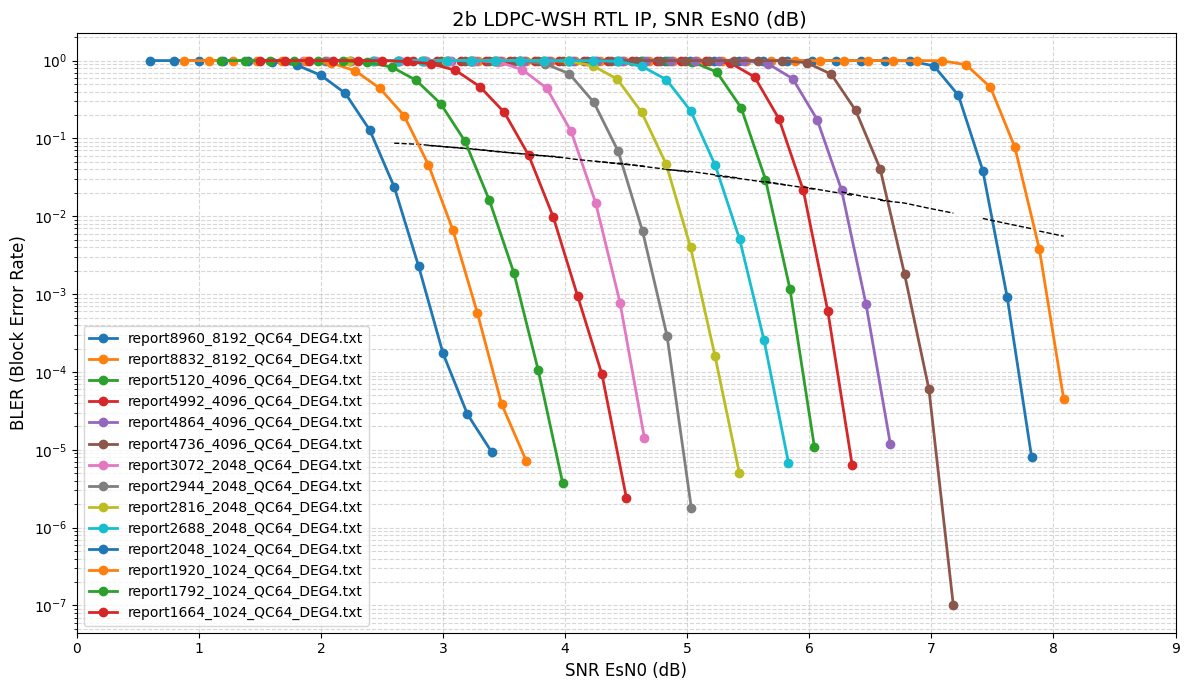

In [4]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

def parse_all_reports(directory="."):
    """
    Scans the directory for report files and parses ECC simulation data
    """
    # Regex to match filenames starting with 'report' and ending with '.txt'
    file_pattern = re.compile(r"report.*\.txt")
    all_data = {}

    for filename in os.listdir(directory):
        if file_pattern.match(filename):
            file_path = os.path.join(directory, filename)
            print(f"Parsing: {filename}")

            with open(file_path, 'r', encoding='utf-8') as f:
                content = f.read()

            # Results storage for the specific file
            file_results = {
                "snr": [],
                "t_block": [],
                "e_block": [],
                "avg_err": [],
                "n_var": None,
                "n_chk": None
            }

            sections = re.split(r'-{30,}', content)

            for section in sections:
                if "SNR" not in section:
                    continue

                # Extract parameters using flexible regex patterns
                snr_match = re.search(r"SNR\s*=\s*([\d\.]+)", section)
                n_var_match = re.search(r"NUM_VAR\s*=\s*(\d+)", section)
                n_chk_match = re.search(r"NUM_CHK\s*=\s*(\d+)", section)
                t_block_match = re.search(r"Total_Block\s*=\s*(\d+)", section)
                e_block_match = re.search(r"Error_Block\s*=\s*(\d+)", section)
                avg_err_match = re.search(r"Average_Error\s*=\s*(\d+)", section)

                if snr_match and t_block_match and e_block_match and avg_err_match:
                    file_results["snr"].append(float(snr_match.group(1)))
                    file_results["t_block"].append(int(t_block_match.group(1)))
                    file_results["e_block"].append(int(e_block_match.group(1)))
                    file_results["avg_err"].append(int(avg_err_match.group(1)))

                    # Capture constants for the file once
                    if file_results["n_var"] is None and n_var_match:
                        file_results["n_var"] = int(n_var_match.group(1))
                    if file_results["n_chk"] is None and n_chk_match:
                        file_results["n_chk"] = int(n_chk_match.group(1))

            # Convert lists to numpy arrays
            for key in ["snr", "t_block", "e_block", "avg_err"]:
                file_results[key] = np.array(file_results[key])

            all_data[filename] = file_results

    return all_data

def get_sort_key(filename):
    """
    Extracts all numbers from the filename to use as a sorting key.
    Returns a tuple of integers found in the string.
    """
    numbers = re.findall(r'\d+', filename)
    return [int(n) for n in numbers]

def plot_waterfall(all_data, use_snr_axis=True):
    """
    Plots the waterfall curve with filenames sorted by numeric values in descending order.
    """
    esn0 = 1

    plt.figure(figsize=(12, 7))

    # Sort filenames: descending order based on the first major number found
    sorted_filenames = sorted(all_data.keys(), key=get_sort_key, reverse=True)

    for filename in sorted_filenames:
        data = all_data[filename]
        if len(data["snr"]) == 0: continue

        bler = data["e_block"] / data["t_block"]

        if use_snr_axis:
            if esn0 :
                x_vals = data["snr"] + 10*np.log10((data["n_var"]-data["n_chk"])*2.0/data["n_var"])
            else :
                x_vals = data["snr"]
            x_label = "SNR EsN0 (dB)"
        else:
            x_vals = data["avg_err"] / data["n_var"]
            x_label = "Raw Bit Error Rate (Average_Error / N)"

        bler[bler==0] = 1e-7
        mask = bler > 0 # Filter for log-scale

        label_name = f"{filename}"
        plt.semilogy(x_vals[mask], bler[mask], 'o-', linewidth=2, label=label_name)

        if use_snr_axis and esn0:
            mask = bler < 0.07
            rber = data["avg_err"] / data["n_var"]
            plt.semilogy(x_vals[mask], rber[mask], 'k--', linewidth=1)
            plt.xlim(0, 9)

    plt.title(f' 2b LDPC-WSH RTL IP, {x_label}', fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel('BLER (Block Error Rate)', fontsize=12)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()

    # Invert x-axis if using normalized error (higher error = worse channel)
    if not use_snr_axis:
        plt.gca().invert_xaxis()

    plt.tight_layout()
    plt.show()

# --- Main Logic ---
if __name__ == "__main__":
    # Parse files
    reports_data = parse_all_reports(".")

    if reports_data:
        # CHOICE: Set to True for SNR, or False for Average_Error/N
        plot_waterfall(reports_data, use_snr_axis=True)
    else:
        print("No 'report*.txt' files found in the directory.")

In [ ]:
!ls

cobj_dir  hstg.txt    libwsh.so     main_wsh.cpp.bak		   sample_data
drive	  ldpc_wsh.v  main_wsh.cpp  report4736_4096_QC64_DEG4.txt  Vldpc_wsh
